<a href="https://colab.research.google.com/github/maxxsaa/CandiInfo/blob/main/qdc_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QDC x Cartier — Data Challenge

**Challenge goals:**
1. **Short-term potential**: Predict client spending in the next 3 years (`TARGET_3Y`).
2. **Lifetime Value (LTV)**: Define and implement a strategy to predict total client value over their relationship with the Maison (validation under limited time data).
3. **Engagement strategy**: How to cater to high-potential clients and measure success over time.

**Important:** `DATE_TARGET` in Aggregated_Data is the cutoff date for each row — only information known up to that date is included. Avoid data leakage when building features.

---    
## 0. Setup and Data Loading

Mount Google Drive to access the datasets.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from pathlib import Path

# Define the path to your dataset folder in Google Drive
DATA_PATH = Path('/content/drive/My Drive/QDC - Team 15/00. Datasets')

# Verify that the path exists
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data path does not exist: {DATA_PATH}. Please check the folder name and ensure it's shared correctly.")
else:
    print(f"Data path set to: {DATA_PATH}")

Data path set to: /content/drive/My Drive/QDC - Team 15/00. Datasets


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


---
## 1. Load datasets

| Dataset | Description |
|---------|-------------|
| **Aggregated_Data** | Client-level aggregates per `DATE_TARGET`; includes `TARGET_3Y`, `TARGET_5Y`, `TARGET_10Y` and many features. |
| **Transactions** | All transactions (sales, repairs) with dates, values, articles, channels. |
| **Clients** | Static client data (country, gender, birth date, first purchase). |
| **CRC** | Customer Relations Center contacts. |
| **CCP** | Cartier Care Program. |
| **Articles** | Article references and characteristics. |
| **savings_rate** | External: global savings rate by date. |

In [ ]:
def load_data(base_path):
    base = Path(base_path)
    # Load aggregated data from parquet, others from csv
    data_dict = {
        "aggregated": pd.read_parquet(base / "aggregated_features.parquet"),
        "transactions": pd.read_csv(base / "Transactions.csv"),
        "clients": pd.read_csv(base / "Clients.csv"),
        "crc": pd.read_csv(base / "CRC.csv"),
        "ccp": pd.read_csv(base / "CCP.csv"),
        "articles": pd.read_csv(base / "Articles.csv"),
        "savings_rate": pd.read_csv(base / "savings_rate.csv"),
    }
    return data_dict

# Load all datasets into a dictionary
data = load_data(DATA_PATH)

# Print the shape (rows x columns) of each loaded DataFrame for an overview
for name, df in data.items():
    print(f"{name:15} {df.shape[0]:>10} rows  x  {df.shape[1]:>3} cols")

aggregated         1517798 rows  x  171 cols
transactions        916957 rows  x   14 cols
clients             412571 rows  x    9 cols
crc                 153949 rows  x    5 cols
ccp                  44280 rows  x    6 cols
articles             72127 rows  x    6 cols
savings_rate           649 rows  x    2 cols


In [ ]:
# Unpack the dictionary of DataFrames into individual variables for easier access
# The 'agg' variable will now directly reference the processed parquet data.
agg_fe = data["aggregated"]
trans = data["transactions"]
clients = data["clients"]
crc = data["crc"]
ccp = data["ccp"]
articles = data["articles"]
savings_rate = data["savings_rate"]

# Display initial information about the new agg_fe to understand its structure
print("First 2 rows of the new agg_fe DataFrame:")
display(agg_fe.head(2))
print("\nColumns in the new agg_fe DataFrame:")
for col in agg_fe.columns:
    print(col)

First 2 rows of the new agg_fe DataFrame:


,CLIENT_ID,DATE_TARGET,TARGET_3Y,TARGET_5Y,TARGET_10Y,AGE,SENIORITY,RESIDENCY_COUNTRY,RESIDENCY_MARKET,GENDER,...,LOG1P_TO_FULL_HIST,LOG1P_TO_JWL,LOG1P_TO_JWL_WAT_HE,LOG1P_TO_MORE_50K,LOG1P_TO_OTHER_HE,LOG1P_TO_PAST_3Y,LOG1P_TO_PAST_3Y_6Y,LOG1P_TO_STDDEV_SPREAD,LOG1P_TO_WAT,LOG1P_TO_WEB
0,b3ee9f248d4fbf96ae05,2006-01-01,0.0,0.0,0.0,42.0,46.0,country_of_residency_119,Residency_Market_14,gender_2,...,6.494540,0.000000,0.0,0.0,0.0,0.000000,6.49454,0.0,0.0,0.0
1,3a30107fce40aef33fe6,2006-01-01,0.0,0.0,0.0,42.0,33.0,country_of_residency_79,Residency_Market_7,gender_2,...,8.716811,8.716811,0.0,0.0,0.0,8.716811,0.00000,0.0,0.0,0.0



Columns in the new agg_fe DataFrame:
CLIENT_ID
DATE_TARGET
TARGET_3Y
TARGET_5Y
TARGET_10Y
AGE
SENIORITY
RESIDENCY_COUNTRY
RESIDENCY_MARKET
GENDER
TO_FULL_HIST
TO_AVG_SPREAD
TO_PAST_3Y
TO_PAST_3Y_6Y
TO_0K_5K
TO_5K_10K
TO_10K_20K
TO_20K_50K
TO_MORE_50K
TO_CRC
TO_WEB
TO_BTQ
TO_ACCESSORIES
TO_FRAGRANCE
TO_JWL
TO_JWL_WAT_HE
TO_OTHER_HE
TO_WAT
TO_STDDEV_SPREAD
AVG_PRICE_PER_PDT
STDDEV_PRICE
AVG_PRICE_PER_TRS
MAX_PRICE_PER_PDT
MAX_PRICE_PER_TRS
MAX_PRICE_IN_CRC
MAX_PRICE_IN_ACCESSORIES
MAX_PRICE_IN_JWL
MAX_PRICE_IN_WAT
MAX_PRICE_IN_WEB
MAX_PRICE_IN_BTQ
NB_TRS_FULL_HIST
NB_MARKET_PURCHASED
NB_CHANNEL
NB_TRS_CRC
NB_TRS_WEB
NB_TRS_BTQ
AVG_TIMELAPSE_PER_TRS
STDDEV_TIMELAPSE_TRS
MIN_TIMELAPSE_TRS
NB_TRS_2M_IN_A_ROW
NB_TRS_2Q_IN_A_ROW
NB_TRS_2S_IN_A_ROW
NB_TRS_2Y_IN_A_ROW
QTY_PDT_FULL_HIST
QTY_PDT_0_5K
QTY_PDT_5K_10K
QTY_PDT_10K_20K
QTY_PDT_20K_50K
QTY_PDT_MORE_50K
QTY_PDT_ACCESSORIES
QTY_PDT_FRAGRANCE
QTY_PDT_WAT
QTY_PDT_JWL
QTY_PDT_JWL_WAT_HE
QTY_PDT_OTHER_HE
QTY_PDT_PRECIOUS_NBS
RECENCY
RECENCY

---    
### 1.1 Feature Engineering for a Common `agg_fe` DataFrame

To ensure consistency and prevent data leakage, we will create a single, feature-engineered version of the aggregated data (`agg_fe`) here. This DataFrame will include:
- Conversion of `DATE_TARGET` to datetime.
- Dropping columns with high missing values or complex list formats.
- Imputation of remaining numerical and categorical missing values.
- One-hot encoding of categorical features.
- **Non-leaking calculation of `TRANS_COUNT`**: Using `pd.merge_asof` to count transactions *up to* each `DATE_TARGET` for each client.
- Merging `SavingsRate` using `pd.merge_asof`.
- Merging `CreationChannel` information.

Subsequent tasks will use `agg_fe` as their base DataFrame, avoiding redundant and potentially inconsistent feature engineering steps.

In [ ]:
import pandas as pd
import numpy as np

# agg_fe is already loaded directly from the pre-engineered parquet file in the previous step.
# No further feature engineering steps (cleaning, imputation, one-hot encoding, feature enrichment)
# are needed here as they are already included in the 'aggregated_features.parquet' dataset.

print(f"Aggregated Feature-Engineered DataFrame (agg_fe) is ready with shape: {agg_fe.shape}")
display(agg_fe.head(2))

Aggregated Feature-Engineered DataFrame (agg_fe) is ready with shape: (1517798, 171)


,CLIENT_ID,DATE_TARGET,TARGET_3Y,TARGET_5Y,TARGET_10Y,AGE,SENIORITY,RESIDENCY_COUNTRY,RESIDENCY_MARKET,GENDER,...,LOG1P_TO_FULL_HIST,LOG1P_TO_JWL,LOG1P_TO_JWL_WAT_HE,LOG1P_TO_MORE_50K,LOG1P_TO_OTHER_HE,LOG1P_TO_PAST_3Y,LOG1P_TO_PAST_3Y_6Y,LOG1P_TO_STDDEV_SPREAD,LOG1P_TO_WAT,LOG1P_TO_WEB
0,b3ee9f248d4fbf96ae05,2006-01-01,0.0,0.0,0.0,42.0,46.0,country_of_residency_119,Residency_Market_14,gender_2,...,6.494540,0.000000,0.0,0.0,0.0,0.000000,6.49454,0.0,0.0,0.0
1,3a30107fce40aef33fe6,2006-01-01,0.0,0.0,0.0,42.0,33.0,country_of_residency_79,Residency_Market_7,gender_2,...,8.716811,8.716811,0.0,0.0,0.0,8.716811,0.00000,0.0,0.0,0.0


---
## 2. Exploratory Data Analysis

### 2.1 Aggregated data (main table for Task 1)

Primary key: `(CLIENT_ID, DATE_TARGET)`. Targets: `TARGET_3Y`, `TARGET_5Y`, `TARGET_10Y` (future spending).

In [ ]:
# Display the data types of the first 30 columns in the aggregated DataFrame.
# Understanding data types is crucial for proper data manipulation and model building.
agg_fe.dtypes.head(30)

,0
CLIENT_ID,object
DATE_TARGET,datetime64[us]
TARGET_3Y,float64
TARGET_5Y,float64
TARGET_10Y,float64
AGE,float64
SENIORITY,float64
RESIDENCY_COUNTRY,string[python]
RESIDENCY_MARKET,string[python]
GENDER,string[python]


In [ ]:
# Convert 'DATE_TARGET' column to datetime objects for proper time-series analysis
# DATE_TARGET represents the cutoff date for each row in the aggregated data, meaning all features
# are computed using information available only up to this date to prevent data leakage.
agg_fe["DATE_TARGET"] = pd.to_datetime(agg_fe["DATE_TARGET"])
# Print the minimum and maximum dates in 'DATE_TARGET' to understand the data's time span
print("DATE_TARGET range:", agg_fe["DATE_TARGET"].min(), "→", agg_fe["DATE_TARGET"].max())
print("\nTarget (future spend) stats:")
# Display descriptive statistics for the target variables (future spending predictions)
# This helps understand their distribution, central tendency, and spread.
print(agg_fe[["TARGET_3Y", "TARGET_5Y", "TARGET_10Y"]].describe())

print("\nPercentage of clients with zero TARGET_3Y:")
print(f"{(agg_fe['TARGET_3Y'] == 0).mean() * 100:.2f}%")

DATE_TARGET range: 2006-01-01 00:00:00 → 2021-01-01 00:00:00

Target (future spend) stats:
          TARGET_3Y     TARGET_5Y    TARGET_10Y
count  1.517798e+06  1.517798e+06  1.517798e+06
mean   2.756184e+02  4.232963e+02  6.047993e+02
std    3.102759e+03  4.134179e+03  5.341676e+03
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    0.000000e+00  0.000000e+00  0.000000e+00
50%    0.000000e+00  0.000000e+00  0.000000e+00
75%    0.000000e+00  0.000000e+00  0.000000e+00
max    5.027778e+05  5.027778e+05  5.041210e+05

Percentage of clients with zero TARGET_3Y:
95.42%


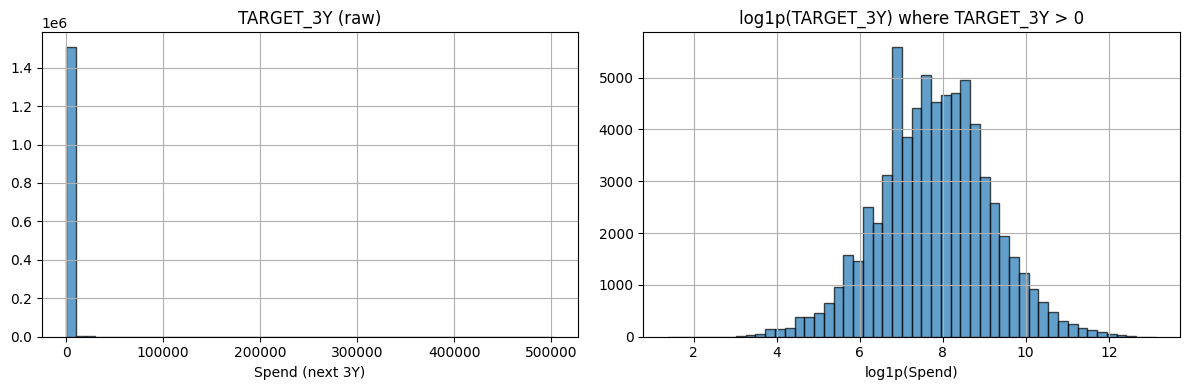

In [ ]:
# Create two subplots for visualizing the distribution of TARGET_3Y
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot the raw distribution of TARGET_3Y
agg_fe["TARGET_3Y"].hist(bins=50, ax=axes[0], edgecolor="black", alpha=0.7)
axes[0].set_title("TARGET_3Y (raw)")
axes[0].set_xlabel("Spend (next 3Y)")

# For the log-transformed distribution, replace zeros with NaN and drop them before applying log1p
# This handles the many zero values and prevents errors with log(0).
# log1p(x) computes log(1+x), which is useful for values that include zero.
# Log transformation is applied because TARGET_3Y is highly skewed (many small values and a few very large ones).
# This helps to normalize the distribution, making it more suitable for models that assume normality,
# reduce the impact of outliers, and often improves model performance by allowing them to learn relationships
# based on relative changes rather than absolute differences.
t = agg_fe["TARGET_3Y"].replace(0, np.nan).dropna()
np.log1p(t).hist(bins=50, ax=axes[1], edgecolor="black", alpha=0.7)
axes[1].set_title("log1p(TARGET_3Y) where TARGET_3Y > 0")
axes[1].set_xlabel("log1p(Spend)")

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show() # Display the plots

In [ ]:
# Calculate the count of missing values for each column in the aggregated DataFrame
missing = agg_fe.isnull().sum()
print("Columns with missing values (top 20):")
# Filter and sort columns by the number of missing values in descending order
print(missing[missing > 0].sort_values(ascending=False).head(20))

Columns with missing values (top 20):
ALL_REPAIR_PDT_CATEG         1286726
ALL_REPAIR_PDT_SUBCATEG      1286726
ALL_REPAIR_PDT_FUNCTION      1286726
ALL_REPAIR_PDT_COLLECTION    1286726
REPAIR_PRICE_RANGE_LAST      1286726
RESIDENCY_MARKET               87660
dtype: int64


### 2.2 Transactions

One row per transaction: channel, article, date, amount (TO_WITHOUTTAX_EUR_CONST), category (Sale/Repair), etc.

In [ ]:
# Convert 'TRS_DATE' column to datetime objects
trans["TRS_DATE"] = pd.to_datetime(trans["TRS_DATE"])
# Print the date range of transactions
print("TRS_DATE range:", trans["TRS_DATE"].min(), "→", trans["TRS_DATE"].max())
# Print the value counts for 'CHANNEL' to see transaction channel distribution
print("\nChannels:", trans["CHANNEL"].value_counts().to_dict())
# Print the value counts for 'TRS_CATEG' to see transaction category distribution
print("\nTRS_CATEG:", trans["TRS_CATEG"].value_counts().to_dict())
print("\nSpend (TO_WITHOUTTAX_EUR_CONST) describe:")
# Display descriptive statistics for the transaction amount (spend)
print(trans["TO_WITHOUTTAX_EUR_CONST"].describe())

TRS_DATE range: 2000-01-03 00:00:00 → 2023-12-31 00:00:00

Channels: {'Boutique': 903545, 'Web': 7573, 'CC': 4666, 'Duty Free': 628, 'Wholesale': 545}

TRS_CATEG: {'Sale': 725473, 'Repair': 191484}

Spend (TO_WITHOUTTAX_EUR_CONST) describe:
count    916535.000000
mean       2168.497758
std        5198.170381
min         -83.600000
25%         217.390000
50%         858.330000
75%        2299.330000
max      286500.000000
Name: TO_WITHOUTTAX_EUR_CONST, dtype: float64


### 2.3 Clients, CRC, CCP, Articles, savings_rate

Quick look at structure and key fields.

In [ ]:
# Print shape and column names for Clients DataFrame
print("Clients:", clients.shape, "| cols:", list(clients.columns))
# Print shape and column names for CRC DataFrame
print("CRC:", crc.shape, "| cols:", list(crc.columns))
# Print shape and column names for CCP DataFrame
print("CCP:", ccp.shape, "| cols:", list(ccp.columns))
# Print shape and column names for Articles DataFrame
print("Articles:", articles.shape, "| cols:", list(articles.columns))
# Print shape for savings_rate DataFrame
print("savings_rate:", savings_rate.shape)
# Convert 'Date' column in savings_rate to datetime objects
savings_rate["Date"] = pd.to_datetime(savings_rate["Date"])
# Print the date range for savings_rate
print("Savings rate date range:", savings_rate["Date"].min(), "→", savings_rate["Date"].max())

Clients: (412571, 9) | cols: ['CLIENT_ID', 'COUNTRY_OF_RESIDENCY', 'GENDER', 'BIRTH_DATE', 'FIRST_PURCHASE_DATE', 'FIRST_TRANSACTION_DATE', 'CAN_BE_CONTACTED', 'CreationChannel', 'MonoMultiMarket']
CRC: (153949, 5) | cols: ['CLIENT_ID', 'CREATION_DATE', 'APPOINTMENT_DURATION', 'ORIGIN', 'APPOINTMENT_ID']
CCP: (44280, 6) | cols: ['CLIENT_ID', 'ARTICLE_ID', 'SERIAL_NUMBER', 'CREATION_DATE', 'SALE_DATE', 'FLAG_GIFT']
Articles: (72127, 6) | cols: ['ARTICLE_ID', 'WORLD_PRICE', 'FLAG_HE', 'FLAG_BRIDAL', 'FLAG_DIAMOND', 'PRODUCT_CATEGORY']
savings_rate: (649, 2)
Savings rate date range: 1995-07-01 00:00:00 → 2049-07-01 00:00:00


---
## 3. Task 1 — Predict spending in the next 3 years (`TARGET_3Y`)

**Goal:** For each client (at a given `DATE_TARGET`), predict the amount they will spend in the next 3 years.


---
### 3.2 Time-Based Train/Test Split

We will split the data into training and testing sets based on `DATE_TARGET` to simulate a real-world scenario where we predict future spending using past data. We'll use data before 2018-01-01 for training and data from 2018-01-01 onwards for testing.

We will add new indicators to try to help the model make its predictions. We enrich the dataframe by adding a transactions count, the client's saving rate and channel creation. These will lead to a strong improvement in the decile capture of the model.

In [ ]:
from sklearn.model_selection import train_test_split

# --- 1. Data Preparation ---
# Use the pre-engineered agg_fe as the base DataFrame for Task 1
df_final = agg_fe.copy()

# --- 2. Final Split ---
target_cols = ['TARGET_3Y', 'TARGET_5Y', 'TARGET_10Y']
id_cols = ['CLIENT_ID', 'DATE_TARGET']

# Select only numeric features, excluding target and ID columns, and any other object columns
# This ensures that raw list-like columns and original categorical columns (if not one-hot encoded in parquet)
# are not passed to XGBoost, adhering to the 'modelling-ready' assumption of the parquet file.
features_task1 = [c for c in df_final.columns
                  if c not in target_cols + id_cols
                  and pd.api.types.is_numeric_dtype(df_final[c])]

cutoff_date = pd.to_datetime('2018-01-01')
train_mask = df_final['DATE_TARGET'] < cutoff_date
test_mask = df_final['DATE_TARGET'] >= cutoff_date

X_train = df_final[train_mask][features_task1]
y_train = df_final[train_mask]['TARGET_3Y']
X_test = df_final[test_mask][features_task1]
y_test = df_final[test_mask]['TARGET_3Y']

# Reindex to ensure feature alignment (important if some features are missing in one set)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Delete df_final to free up memory as X_train, y_train, X_test, y_test are now created
del df_final

Training set shape: (754989, 153)
Testing set shape: (762809, 153)


---
### 3.3 Model Training and Evaluation

We'll use an XGBoost Regressor for prediction. Given the highly skewed nature of `TARGET_3Y`, we will apply a `log1p` transformation to the target variable before training and inverse transform the predictions for evaluation.

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr

# Apply log1p transformation to the target variable
y_train_log = np.log1p(y_train)

# Initialize and train the XGBoost Regressor model
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

print("Training Improved XGBoost Regressor for Task 1 (3Y)...")
model.fit(X_train, y_train_log)

# Make predictions on the test set
predictions = np.expm1(model.predict(X_test))
predictions[predictions < 0] = 0

# Evaluate the model's performance
rmse_direct_reg = np.sqrt(mean_squared_error(y_test, predictions))
r2_direct_reg = r2_score(y_test, predictions)

print(f"\nEvaluation (Enriched Features):")
print(f"RMSE: {rmse_direct_reg:.2f}")
print(f"R-squared: {r2_direct_reg:.4f}")

# Ranking Metrics
spearman_corr, _ = spearmanr(y_test, predictions)
print(f"Spearman Correlation: {spearman_corr:.4f}")

results_df = pd.DataFrame({'true': y_test, 'pred': predictions}).sort_values('pred', ascending=False)
top_10_cap = (results_df.head(int(len(results_df)*0.1))['true'].sum() / y_test.sum()) * 100
print(f"Top 10% Capture: {top_10_cap:.2f}%")

Training Improved XGBoost Regressor for Task 1 (3Y)...

Evaluation (Enriched Features):
RMSE: 3005.27
R-squared: -0.0054
Spearman Correlation: 0.2117
Top 10% Capture: 53.16%


---
### 3.4 Refined Approach for Task 1: Two-Part Model

Given the highly skewed distribution of `TARGET_3Y` with a significant number of zero values, a single regression model struggles to perform well. We will adopt a two-part modeling approach:

1.  **Classification Model**: Predict whether a client will spend *any* amount in the next 3 years (i.e., `TARGET_3Y > 0`).
2.  **Regression Model**: If a client is predicted to spend (from the classification step), then predict the *amount* of their spending, focusing only on clients with `TARGET_3Y > 0`. This will be built on the `log1p` transformed target for non-zero values.

First, let's prepare the target variable for the classification task.

In [ ]:
# Create a binary target for the classification task: 1 if TARGET_3Y > 0, else 0
# Use agg_fe as it contains all the enriched features
agg_fe['HAS_SPENT_3Y'] = (agg_fe['TARGET_3Y'] > 0).astype(int)

# Re-define features (X) and target (y_clf) using the correct dataframe
X_clf = agg_fe[features_task1]
y_clf = agg_fe['HAS_SPENT_3Y']

# Split data for classification task using the same cutoff date
cutoff_date = pd.to_datetime('2018-01-01')
train_mask_clf = agg_fe['DATE_TARGET'] < cutoff_date
test_mask_clf = agg_fe['DATE_TARGET'] >= cutoff_date

X_train_clf = X_clf[train_mask_clf]
y_train_clf = y_clf[train_mask_clf]

X_test_clf = X_clf[test_mask_clf]
y_test_clf = y_clf[test_mask_clf]

print(f"Training set shape for Classification: {X_train_clf.shape}")
print(f"Testing set shape for Classification: {X_test_clf.shape}")

print("\nDistribution of HAS_SPENT_3Y in training set:")
print(y_train_clf.value_counts(normalize=True))
print("\nDistribution of HAS_SPENT_3Y in testing set:")
print(y_test_clf.value_counts(normalize=True))

Training set shape for Classification: (754989, 153)
Testing set shape for Classification: (762809, 153)

Distribution of HAS_SPENT_3Y in training set:
HAS_SPENT_3Y
0    0.951741
1    0.048259
Name: proportion, dtype: float64

Distribution of HAS_SPENT_3Y in testing set:
HAS_SPENT_3Y
0    0.956567
1    0.043433
Name: proportion, dtype: float64


---
### 3.4.1 Classification Model: Predict if client will spend (`HAS_SPENT_3Y`)

We will use an XGBoost Classifier due to its robustness and performance with imbalanced datasets (even though we have a strong majority of zeros, XGBoost can handle it well).

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize and train the XGBoost Classifier
clf_model = xgb.XGBClassifier(
    objective='binary:logistic', # For binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=(len(y_train_clf) - y_train_clf.sum()) / y_train_clf.sum() # Handle class imbalance
)

print("Training XGBoost Classifier...")
clf_model.fit(X_train_clf, y_train_clf)
print("Training complete.")

# Make predictions on the test set
clf_preds = clf_model.predict(X_test_clf)
clf_proba = clf_model.predict_proba(X_test_clf)[:, 1] # Probability of spending

# Evaluate the classifier
accuracy = accuracy_score(y_test_clf, clf_preds)
precision = precision_score(y_test_clf, clf_preds)
recall = recall_score(y_test_clf, clf_preds)
f1 = f1_score(y_test_clf, clf_preds)
roc_auc = roc_auc_score(y_test_clf, clf_proba)

print(f"\nClassification Model Evaluation on Test Set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Training XGBoost Classifier...
Training complete.

Classification Model Evaluation on Test Set:
Accuracy: 0.6833
Precision: 0.0986
Recall: 0.7727
F1-Score: 0.1749
ROC AUC: 0.8056


---
### 3.4.2 Regression Model: Predict spending amount for those who will spend (`TARGET_3Y > 0`)

Now, we'll train a regression model *only* on the subset of the training data where `TARGET_3Y` is greater than 0. We will also apply the `log1p` transformation to the target.

In [ ]:
# Filter training data to include only clients who spent (TARGET_3Y > 0)
X_train_reg = X_train[y_train > 0]
y_train_reg = y_train[y_train > 0]

# Apply log1p transformation to the target for regression
y_train_reg_log = np.log1p(y_train_reg)

# Initialize and train the XGBoost Regressor model
reg_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost Regressor for non-zero spenders...")
reg_model.fit(X_train_reg, y_train_reg_log)
print("Training complete.")

Training XGBoost Regressor for non-zero spenders...
Training complete.


---
### 3.4.3 Combine Predictions and Evaluate Two-Part Model

Finally, we combine the predictions from the classification and regression models to get our final `TARGET_3Y` predictions. If the classifier predicts no spending, the final prediction is 0. Otherwise, we use the regression model's output.

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr

# Hurdle Model Implementation:
# 1. Predict the probability of spending for all test clients using the classifier.
# 2. Predict the potential spending amount for all test clients using the regression model.
# 3. Multiply these two components to get the final expected spending.

# Step 1: Get probabilities of spending from the classifier
# clf_proba is already calculated in the previous cell (06271366)
# clf_proba = clf_model.predict_proba(X_test_clf)[:, 1]

# Step 2: Make regression predictions for ALL test clients
# The regression model was trained on non-zero spenders. We assume it generalizes to potential spending for all.
reg_preds_log_all = reg_model.predict(X_test_clf)
reg_preds_all = np.expm1(reg_preds_log_all)

# Ensure no negative predictions (can happen with expm1 on very small negative log values)
reg_preds_all[reg_preds_all < 0] = 0

# Step 3: Combine predictions (Hurdle Model: P(spend) * Predicted_Amount_if_Spend)
final_predictions = clf_proba * reg_preds_all

# Evaluate the combined two-part model
rmse_hurdle = np.sqrt(mean_squared_error(y_test, final_predictions))
mae_hurdle = mean_absolute_error(y_test, final_predictions)
r2_hurdle = r2_score(y_test, final_predictions)

print(f"\nCombined Hurdle Model Evaluation on Test Set (Original Scale):")
print(f"RMSE: {rmse_hurdle:.2f}")
print(f"MAE: {mae_hurdle:.2f}")
print(f"R-squared: {r2_hurdle:.4f}")

# Additional Metrics:

# Spearman Rank Correlation
# This assesses how well the model ranks clients by spending, which is crucial for engagement strategies.
# Handle cases where y_test might have zero variance (e.g., all zeros) to avoid errors.
if y_test.std() != 0 and final_predictions.std() != 0:
    spearman_corr_hurdle, _ = spearmanr(y_test, final_predictions)
    print(f"Spearman Correlation: {spearman_corr_hurdle:.4f}")
else:
    spearman_corr_hurdle = np.nan
    print("Spearman Correlation: Cannot compute (insufficient variance in target/predictions).")

# Top-Decile Capture
# This measures the percentage of actual total spending captured by the top 10% of predicted spenders.
results_df = pd.DataFrame({'true_spend': y_test, 'predicted_spend': final_predictions})
results_df_sorted = results_df.sort_values(by='predicted_spend', ascending=False)

top_10_percent_count = int(len(results_df_sorted) * 0.1)
top_10_percent_df = results_df_sorted.head(top_10_percent_count)

total_true_spend = y_test.sum()

if total_true_spend > 0:
    top_decile_capture_hurdle = (top_10_percent_df['true_spend'].sum() / total_true_spend) * 100
    print(f"Top 10% Predicted Clients Capture {top_decile_capture_hurdle:.2f}% of Total Actual Spend")
else:
    top_decile_capture_hurdle = np.nan
    print("Top 10% Predicted Clients Capture: Cannot compute (total actual spend is zero).")


Combined Hurdle Model Evaluation on Test Set (Original Scale):
RMSE: 3056.84
MAE: 1085.15
R-squared: -0.0403
Spearman Correlation: 0.1806
Top 10% Predicted Clients Capture 51.93% of Total Actual Spend


The improvements also had good effects here. We observe however that the two-step process did not improve our predictions, and the predicted top 10% of clients actually captures less of the actual revenue than the first model.

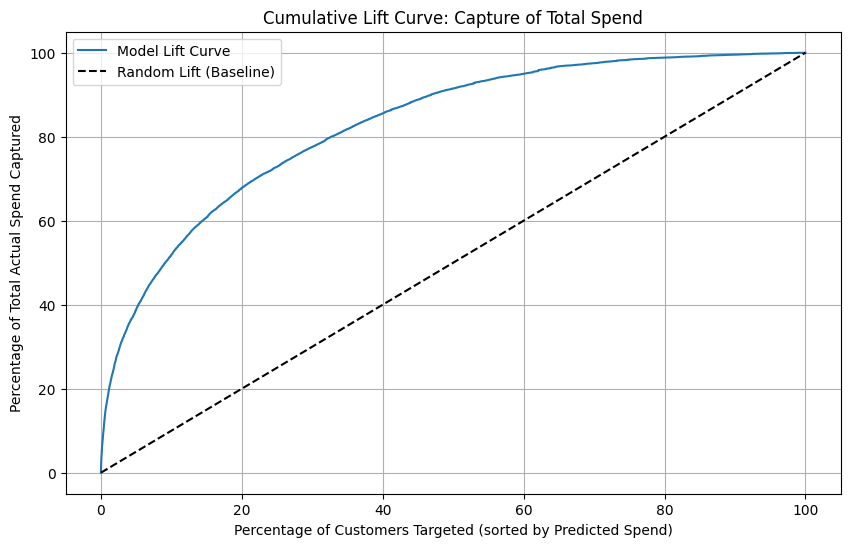

Targeting top 5% of customers captures 38.81% of total actual spend.
Targeting top 10% of customers captures 51.93% of total actual spend.
Targeting top 20% of customers captures 67.83% of total actual spend.
Targeting top 30% of customers captures 77.57% of total actual spend.
Targeting top 50% of customers captures 91.50% of total actual spend.


In [ ]:
import matplotlib.pyplot as plt

# Create a DataFrame with true and predicted spend
results_df = pd.DataFrame({'true_spend': y_test, 'predicted_spend': final_predictions})

# Sort by predicted spend in descending order
results_df_sorted = results_df.sort_values(by='predicted_spend', ascending=False).reset_index(drop=True)

# Calculate cumulative actual spend
results_df_sorted['cumulative_actual_spend'] = results_df_sorted['true_spend'].cumsum()

# Calculate cumulative percentage of total actual spend
total_actual_spend = y_test.sum()
results_df_sorted['cumulative_percent_actual_spend'] = (results_df_sorted['cumulative_actual_spend'] / total_actual_spend) * 100

# Calculate cumulative percentage of customers targeted
results_df_sorted['cumulative_percent_customers'] = ((results_df_sorted.index + 1) / len(results_df_sorted)) * 100

# Plot the Cumulative Lift Curve
plt.figure(figsize=(10, 6))
plt.plot(results_df_sorted['cumulative_percent_customers'], results_df_sorted['cumulative_percent_actual_spend'], label='Model Lift Curve')
plt.plot([0, 100], [0, 100], 'k--', label='Random Lift (Baseline)')
plt.title('Cumulative Lift Curve: Capture of Total Spend')
plt.xlabel('Percentage of Customers Targeted (sorted by Predicted Spend)')
plt.ylabel('Percentage of Total Actual Spend Captured')
plt.grid(True)
plt.legend()
plt.show()

# Example points on the curve (e.g., top 10%, 20%, 30%)
for p in [5, 10, 20, 30, 50]:
    idx = int(len(results_df_sorted) * (p / 100))
    if idx > 0:
        captured_spend = results_df_sorted.loc[idx - 1, 'cumulative_percent_actual_spend']
        print(f"Targeting top {p}% of customers captures {captured_spend:.2f}% of total actual spend.")

We observe that the model offers a very upward-lifting curve. This means that a very small percentage of Cartier's customers are responsible for most of its revenue. We compare it to a baseline (straight line in the graph) that represents a standard situation where x% of the clients capture x% of the revenue (their own weight).

In our situation, targeting only 10% of Cartier's customers can capture more than half of its revenues.

---
### 3.4.5 VIP Identification and Lift Analysis

We observe that when we use standard metrics like precision, recall and F1-score, the models we use perform very poorly. This is logical since the dataset is heavily skewed (a lot of the clients do not bring any revenue). A much better way to identify VIPs is to identify the top percentiles of clients by revenue they bring. Instead of predicting revenue amounts, we predict the rank of each client. To do so, we'll generate a cumulative lift curve and calculate Precision@K and Recall@K to assess how well the model identifies top spenders.

Precision@K is a metric that indicates the precision of the K% decile we aim for. It answers "Among the top K predicted clients, how many are actually top spenders?"

Recall@K is a metric that indicates the recall of the K% decile we aim for. It answers the question: "Of all the real high-value clients, how many did we successfully identify?"

The lift curve represents the percentage of the total revenue that is captured, by the percentage of customers we target. This reveals how much revenue can be captured by targeting only a part of all customers (revenue concentration).

---
### 3.4.6 Precision@K and Recall@K for High-Value Client Identification

To define "high-value clients" for the purpose of Precision@K and Recall@K, we first need to identify the top X% of true spenders in the test set. Then, we can evaluate how many of these true high-value clients are correctly identified by our model within its predicted top Y%.

For this analysis, let's define `True VIPs` as clients who fall into the **top 10% of actual spenders** in the test set (`y_test`). We will then assess the model's ability to identify these VIPs at different 'K' values (e.g., top 5%, 10%, 20% of predicted clients).

In [ ]:
# Define 'True VIPs' as the top 10% of actual spenders in the test set
# To handle the many zero values, we calculate the quantile only among clients who actually spent > 0.
# This ensures our VIPs are genuinely high-value.
non_zero_spenders = y_test[y_test > 0]
vip_threshold = non_zero_spenders.quantile(0.90) if not non_zero_spenders.empty else 0.0 # Define VIP threshold from non-zero spenders
true_vips = y_test[y_test >= vip_threshold].index # Select clients whose spend is above this threshold

# Create a DataFrame to store actual and predicted VIP status
evaluation_df = pd.DataFrame({'true_spend': y_test, 'predicted_spend': final_predictions})
evaluation_df['is_true_vip'] = (evaluation_df['true_spend'] >= vip_threshold).astype(int)

# Sort by predicted spend in descending order to identify predicted VIPs
evaluation_df_sorted = evaluation_df.sort_values(by='predicted_spend', ascending=False).reset_index(drop=True)

print(f"Spending threshold for a True VIP (top 10% of non-zero y_test): {vip_threshold:.2f}")
print(f"Number of True VIPs in test set: {evaluation_df['is_true_vip'].sum()}")

def calculate_precision_recall_at_k(df_sorted, k_percent, true_vip_col='is_true_vip'):
    num_predictions_at_k = int(len(df_sorted) * (k_percent / 100))
    if num_predictions_at_k == 0: # Handle cases where k_percent is too small
        return 0.0, 0.0

    predicted_at_k = df_sorted.head(num_predictions_at_k)

    # Precision@K: Proportion of correctly identified VIPs among the top K predicted
    true_positives = predicted_at_k[true_vip_col].sum()
    precision_at_k = true_positives / num_predictions_at_k if num_predictions_at_k > 0 else 0

    # Recall@K: Proportion of true VIPs identified among all true VIPs
    total_true_vips = df_sorted[true_vip_col].sum()
    recall_at_k = true_positives / total_true_vips if total_true_vips > 0 else 0

    return precision_at_k, recall_at_k

print("\n--- Metrics for VIP Identification (True VIPs = top 10% actual non-zero spenders) ---")
for k in [5, 10, 20]:
    prec, rec = calculate_precision_recall_at_k(evaluation_df_sorted, k)
    print(f"At K = {k}% of predicted clients:")
    print(f"  Precision@{k}%: {prec:.4f} (Proportion of predicted top {k}% who are actual VIPs)")
    print(f"  Recall@{k}%: {rec:.4f} (Proportion of actual VIPs captured by predicted top {k}%)")

Spending threshold for a True VIP (top 10% of non-zero y_test): 13691.52
Number of True VIPs in test set: 3314

--- Metrics for VIP Identification (True VIPs = top 10% actual non-zero spenders) ---
At K = 5% of predicted clients:
  Precision@5%: 0.0420 (Proportion of predicted top 5% who are actual VIPs)
  Recall@5%: 0.4831 (Proportion of actual VIPs captured by predicted top 5%)
At K = 10% of predicted clients:
  Precision@10%: 0.0271 (Proportion of predicted top 10% who are actual VIPs)
  Recall@10%: 0.6228 (Proportion of actual VIPs captured by predicted top 10%)
At K = 20% of predicted clients:
  Precision@20%: 0.0166 (Proportion of predicted top 20% who are actual VIPs)
  Recall@20%: 0.7652 (Proportion of actual VIPs captured by predicted top 20%)


### 3.5 The Importance of Ranking and VIP Identification Metrics

Here is a final recap of each models performances by their metrics. Since the dataset is highly skewed and most customers do not bring any revenue, standard metrics like F1-score, global precision or recall, MSE, ... are not the most relevant. Cartier's objective is to identify its VIPs to target them more efficiently. Therefore, a model that aims at ranking its customers rather than trying to estimate their individual revenues is much more efficient at helping the company at targeting the right customers.

In [ ]:
import pandas as pd

# Re-calculate MAE for the direct regression model as it was not stored before
# Note: mae_direct_reg was not present after the latest modifications to cell f338d824
# We will re-calculate it for consistency.
mae_direct_reg = mean_absolute_error(y_test, predictions)

# Create a dictionary to store metrics for comparison
comparison_metrics = {
    'Metric': ['RMSE', 'MAE', 'R-squared', 'Spearman Correlation', 'Top 10% Capture (%)'],
    'Direct Regression Model': [
        f"{rmse_direct_reg:.2f}",
        f"{mae_direct_reg:.2f}",
        f"{r2_direct_reg:.4f}",
        f"{spearman_corr:.4f}", # Using 'spearman_corr' from the last direct regression run
        f"{top_10_cap:.2f}"      # Using 'top_10_cap' from the last direct regression run
    ],
    'Hurdle Model': [
        f"{rmse_hurdle:.2f}",
        f"{mae_hurdle:.2f}",
        f"{r2_hurdle:.4f}",
        f"{spearman_corr_hurdle:.4f}",
        f"{top_decile_capture_hurdle:.2f}"
    ]
}

# Create a DataFrame for the comparison
comparison_df = pd.DataFrame(comparison_metrics)

display(comparison_df)

,Metric,Direct Regression Model,Hurdle Model
0,RMSE,3005.27,3056.84
1,MAE,277.45,1085.15
2,R-squared,-0.0054,-0.0403
3,Spearman Correlation,0.2117,0.1806
4,Top 10% Capture (%),53.16,51.93


## 4. Task 2 — Lifetime Value (LTV) Prediction

**Goal:** Predict the long-term value of clients over a 10-year horizon using `TARGET_10Y` as a proxy. We will compare three modeling approaches to find the most efficient strategy for identifying high-value clients.

### 4.1 Independent Data Preparation and Feature Engineering
We create a specific dataset for Task 2. This includes cleaning high-null columns and enriching the data with transaction frequency, macro-economic context (Savings Rate), and acquisition channels.

In [ ]:
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import spearmanr

# Use the pre-engineered agg_fe as the base DataFrame for Task 2
df_ltv = agg_fe.copy()

print(f"Enriched Dataset Ready: {df_ltv.shape[0]} rows")

Enriched Dataset Ready: 1517798 rows


### 4.2 Modeling Strategies
We evaluate three approaches to predict 10-year LTV:
1.  **Baseline**: Direct XGBoost Regression using only basic features.
2.  **Basic Hurdle**: Two-stage model (Classifier + Regressor) using basic features.
3.  **Improved Hurdle**: Two-stage model using enriched features (Frequency, Economics, Channels).

In [ ]:
# Define Feature Sets
# Features are now derived directly from the 'agg_fe' DataFrame, ensuring they are numeric
# and present in the parquet file.

# All numeric columns in agg_fe that are not target or ID columns
all_numeric_features = [c for c in df_ltv.columns
                        if c not in ['CLIENT_ID', 'DATE_TARGET', 'TARGET_3Y', 'TARGET_5Y', 'TARGET_10Y']
                        and pd.api.types.is_numeric_dtype(df_ltv[c])]

# Baseline features (subset of all numeric features)
baseline_feats = ['AGE', 'SENIORITY', 'TO_FULL_HIST', 'TO_PAST_3Y', 'TO_PAST_3Y_6Y', 'TO_AVG_SPREAD', 'TO_BTQ', 'TO_WEB', 'TO_CRC', 'TO_JWL', 'TO_WAT']
# Filter baseline_feats to ensure they are actually present in the all_numeric_features list
baseline_feats = [f for f in baseline_feats if f in all_numeric_features]

# No separate 'encoded_feats' needed as categorical features are expected to be encoded or handled otherwise
# by the 'all_numeric_features' selection if they are in the parquet.
# If string categoricals exist, they are filtered out by pd.api.types.is_numeric_dtype.

# base_total for the baseline model will just be the refined baseline_feats
base_total = baseline_feats

# Enriched features: include all numeric features (implicitly includes SavingsRate, LOG1P_*, HAS_*, MISSING_*)
# Explicitly add 'SavingsRate' here, but it should already be covered by all_numeric_features
enriched_total = list(set(all_numeric_features)) # Use set to avoid duplicates and ensure all numeric are included

# Time-Based Split
cutoff = pd.to_datetime('2011-01-01')
train = df_ltv[df_ltv['DATE_TARGET'] < cutoff]
test = df_ltv[df_ltv['DATE_TARGET'] >= cutoff]
y_test_ltv = test['TARGET_10Y']

def run_hurdle(train_df, test_df, features):
    # Stage 1: Classification
    clf = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
    clf.fit(train_df[features], (train_df['TARGET_10Y'] > 0).astype(int))
    # Stage 2: Regression (on log-target for spenders)
    mask = train_df['TARGET_10Y'] > 0
    reg = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
    reg.fit(train_df[mask][features], np.log1p(train_df[mask]['TARGET_10Y']))
    # Combine
    prob = clf.predict_proba(test_df[features])[:, 1]
    amt = np.expm1(reg.predict(test_df[features]))
    return prob * amt

# Model 1: Baseline Direct Regression
model_base = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
model_base.fit(train[base_total], np.log1p(train['TARGET_10Y']))
pred_baseline = np.expm1(model_base.predict(test[base_total]))

# Model 2: Basic Hurdle
pred_hurdle_basic = run_hurdle(train, test, base_total)

# Model 3: Improved Hurdle (Enriched)
pred_hurdle_imp = run_hurdle(train, test, enriched_total)

print("Models training and prediction completed.")

Models training and prediction completed.


### 4.3 Comparison of Results
We compare models using standard regression metrics and the **Top 10% Capture**, which measures the percentage of total 10-year revenue generated by the top 10% of predicted clients.

,Metric,Baseline (Basic Features),Basic Hurdle,Improved Hurdle (Enriched)
0,RMSE,5061.69,4925.34,4904.24
1,R-squared,-0.0024,0.0509,0.0590
2,Top 10% Capture,39.56%,44.75%,45.99%


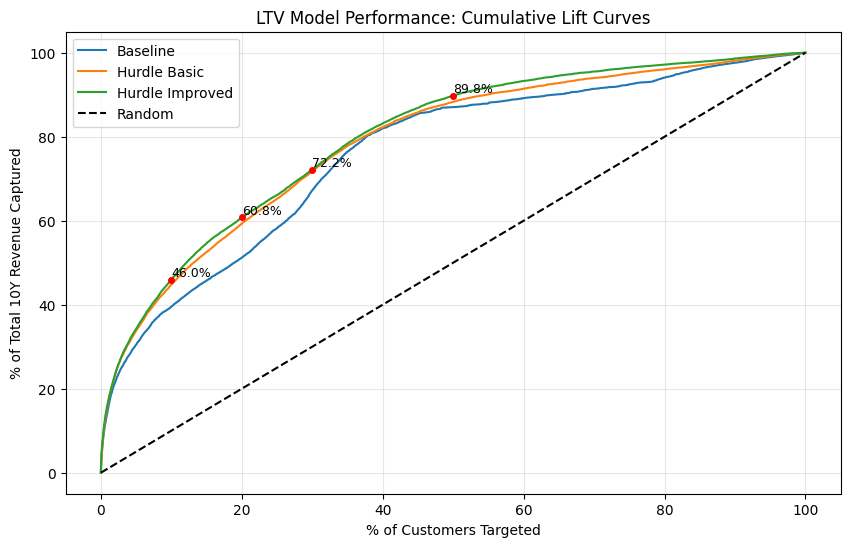

In [ ]:
def evaluate_ltv(true, pred):
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2 = r2_score(true, pred)
    res = pd.DataFrame({'t': true, 'p': pred}).sort_values('p', ascending=False)
    cap10 = (res.head(int(len(res)*0.1))['t'].sum() / true.sum()) * 100
    return [f"{rmse:.2f}", f"{r2:.4f}", f"{cap10:.2f}%"]

metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'R-squared', 'Top 10% Capture'],
    'Baseline (Basic Features)': evaluate_ltv(y_test_ltv, pred_baseline),
    'Basic Hurdle': evaluate_ltv(y_test_ltv, pred_hurdle_basic),
    'Improved Hurdle (Enriched)': evaluate_ltv(y_test_ltv, pred_hurdle_imp)
})

display(metrics_df)

# Lift Curve Plot
plt.figure(figsize=(10, 6))

# Data for the improved hurdle model to add annotations
ltv_eval_df = pd.DataFrame({'t': y_test_ltv, 'p': pred_hurdle_imp}).sort_values('p', ascending=False).reset_index()
ltv_eval_df['cumulative_percent_customers'] = ((ltv_eval_df.index + 1) / len(ltv_eval_df)) * 100
ltv_eval_df['cumulative_percent_actual_spend'] = (ltv_eval_df['t'].cumsum() / y_test_ltv.sum()) * 100

for p, label in zip([pred_baseline, pred_hurdle_basic, pred_hurdle_imp], ['Baseline', 'Hurdle Basic', 'Hurdle Improved']):
    eval_df = pd.DataFrame({'t': y_test_ltv, 'p': p}).sort_values('p', ascending=False).reset_index()
    plt.plot((eval_df.index+1)/len(eval_df)*100, eval_df['t'].cumsum()/y_test_ltv.sum()*100, label=label)

plt.plot([0,100], [0,100], 'k--', label='Random')
plt.title("LTV Model Performance: Cumulative Lift Curves")
plt.xlabel("% of Customers Targeted")
plt.ylabel("% of Total 10Y Revenue Captured")
plt.legend(); plt.grid(True, alpha=0.3)

# Add annotations for the 'Hurdle Improved' model
for k_percent in [10, 20, 30, 50]:
    # Find the closest data point for the given k_percent of customers
    idx = (np.abs(ltv_eval_df['cumulative_percent_customers'] - k_percent)).idxmin()
    customer_pct = ltv_eval_df.loc[idx, 'cumulative_percent_customers']
    revenue_pct = ltv_eval_df.loc[idx, 'cumulative_percent_actual_spend']

    # Add text annotation on the plot
    plt.text(customer_pct, revenue_pct, f'{revenue_pct:.1f}%',
             fontsize=9, ha='left', va='bottom', color='black')
    plt.plot(customer_pct, revenue_pct, 'ro', markersize=4)

plt.show()

## 5. Task 3 — Engagement Strategy & Customer Segmentation

Following our LTV modeling, we now translate these predictions into actionable business segments. We will define our **VIP segment** as the top 10% of clients by predicted LTV and analyze their unique traits, followed by behavioral clustering to identify high-level customer archetypes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# --- 1. Data Preparation ---
# Use the pre-engineered agg_fe as the base DataFrame for Task 3
df_task3 = agg_fe.copy()

# --- 2. Model Training (To get LTV Predictions) ---
# IMPORTANT: Ensure features are strictly numeric
features_t3 = [c for c in df_task3.columns if c not in ['CLIENT_ID', 'DATE_TARGET', 'TARGET_3Y', 'TARGET_5Y', 'TARGET_10Y']]
# Filter out any remaining non-numeric columns (should be minimal with agg_fe)
features_t3 = [c for c in features_t3 if df_task3[c].dtype in ['int64', 'float64', 'bool', 'uint8']]

cutoff_t3 = pd.to_datetime('2011-01-01')
train_t3 = df_task3[df_task3['DATE_TARGET'] < cutoff_t3]
test_t3 = df_task3[df_task3['DATE_TARGET'] >= cutoff_t3]

# Simple Hurdle Model for LTV ranking
clf_t3 = xgb.XGBClassifier(
    objective='binary:logistic', # For binary classification
    n_estimators=100, # Aligned to 100
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
clf_t3.fit(train_t3[features_t3], (train_t3['TARGET_10Y'] > 0).astype(int))

mask_train = train_t3['TARGET_10Y'] > 0
reg_t3 = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100, # Aligned to 100
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
reg_t3.fit(train_t3[mask_train][features_t3], np.log1p(train_t3[mask_train]['TARGET_10Y']))

# Combine for ranking
prob_t3 = clf_t3.predict_proba(test_t3[features_t3])[:, 1]
amt_t3 = np.expm1(reg_t3.predict(test_t3[features_t3]))
pred_LTV_t3 = prob_t3 * amt_t3

# --- 3. Segmentation Analysis ---
eval_df = test_t3[['CLIENT_ID', 'AGE', 'SENIORITY', 'TO_FULL_HIST', 'TO_PAST_3Y', 'TO_BTQ', 'TO_WEB', 'TO_CRC', 'TARGET_10Y']].copy()
eval_df['pred_LTV'] = pred_LTV_t3

# Calculate Engagement_Score here to ensure it's available
eval_df['Engagement_Score'] = eval_df['TO_PAST_3Y'] / (eval_df['TO_PAST_3Y'].mean() + 1)

threshold_10 = eval_df['pred_LTV'].quantile(0.90)
eval_df['Segment'] = np.where(eval_df['pred_LTV'] >= threshold_10, 'VIP', 'Standard')

# Define Strategic Quadrants within this cell
ltv_threshold = eval_df['pred_LTV'].quantile(0.75)
eng_threshold = eval_df['Engagement_Score'].quantile(0.75)

# Map clients to strategic quadrants
eval_df['Strategic_Quadrant'] = np.where(eval_df['pred_LTV'] > ltv_threshold,
                                          np.where(eval_df['Engagement_Score'] > eng_threshold, 'Champions', 'High Potential'),
                                          np.where(eval_df['Engagement_Score'] > eng_threshold, 'Loyal/Low-Value', 'At-Risk'))

comparison = eval_df.groupby('Segment')[['AGE', 'SENIORITY', 'TO_FULL_HIST', 'TO_PAST_3Y', 'TO_BTQ']].mean()
print("Average Behavioral Traits: VIP vs Standard Clients")
display(comparison)


Average Behavioral Traits: VIP vs Standard Clients


,AGE,SENIORITY,TO_FULL_HIST,TO_PAST_3Y,TO_BTQ
Segment,,,,,
Standard,42.852490,108.366599,3063.526554,610.543342,3053.129337
VIP,46.164864,88.176936,14620.636076,4727.747767,14580.969533


In [ ]:
print("Engagement_Score value counts (top 10):")
print(eval_df['Engagement_Score'].value_counts().head(10))

print(f"\nMedian Engagement_Score: {eval_df['Engagement_Score'].median()}")
print(f"Median TO_PAST_3Y: {eval_df['TO_PAST_3Y'].median()}")

Engagement_Score value counts (top 10):
Engagement_Score
0.000000    957017
0.456048      5039
0.895806      3438
1.050532      3241
4.926916      3231
0.838793      3018
0.765501      2991
1.245980      2098
1.302982      1847
0.735382      1750
Name: count, dtype: int64

Median Engagement_Score: 0.0
Median TO_PAST_3Y: 0.0


In [ ]:
# 3. Behavioral Clustering (Archetypes)
cluster_cols = ['SENIORITY', 'TO_FULL_HIST', 'TO_PAST_3Y', 'TO_BTQ', 'TO_WEB', 'TO_CRC']
X_cluster = eval_df[cluster_cols].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Applying K-Means (4 clusters as a starting archetype count)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
eval_df['Cluster'] = kmeans.fit_transform(X_scaled).argmin(axis=1) # Simplified assignment
eval_df['Cluster'] = kmeans.labels_

cluster_summary = eval_df.groupby('Cluster').agg({
    'CLIENT_ID': 'count',
    'TO_FULL_HIST': 'mean',
    'TO_BTQ': 'mean',
    'TO_WEB': 'mean',
    'SENIORITY': 'mean',
    'pred_LTV': 'mean'
}).rename(columns={'CLIENT_ID': 'Client_Count'})

print("\nCustomer Archetype Clusters Summary:")
display(cluster_summary)

print("\nArchetype Mapping Hypothesis:")
print("Cluster with high TO_BTQ -> Boutique Loyalists")
print("Cluster with high TO_WEB -> Digital/Modern Buyers")
print("Cluster with high SENIORITY + low recent spend -> Dormant Historics")


Customer Archetype Clusters Summary:


,Client_Count,TO_FULL_HIST,TO_BTQ,TO_WEB,SENIORITY,pred_LTV
Cluster,,,,,,
0,508121,3143.063951,3142.087164,0.279209,179.330913,345.240845
1,740275,3775.898461,3759.077882,5.758641,56.159815,677.914673
2,672,8755.729328,3147.016573,4966.444239,46.720238,2021.276367
3,9158,99443.931942,99438.712299,0.425675,118.178751,7047.807129



Archetype Mapping Hypothesis:
Cluster with high TO_BTQ -> Boutique Loyalists
Cluster with high TO_WEB -> Digital/Modern Buyers
Cluster with high SENIORITY + low recent spend -> Dormant Historics


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from pathlib import Path

df_task3 = agg_fe.copy()

# IMPORTANT: Ensure features are strictly numeric
features_t3 = [c for c in df_task3.columns
                  if c not in ['CLIENT_ID', 'DATE_TARGET', 'TARGET_3Y', 'TARGET_5Y', 'TARGET_10Y']
                  and pd.api.types.is_numeric_dtype(df_task3[c])]

In [ ]:
# 5. Tracking Metrics
# Summary of potential segment migration targets
tracking_summary = eval_df.groupby('Strategic_Quadrant').agg({
    'TO_PAST_3Y': 'sum',
    'pred_LTV': 'mean',
    'SENIORITY': 'mean'
}).rename(columns={'TO_PAST_3Y': 'Total_Recent_Revenue'})

print("\nEngagement Strategy Tracking Metrics:")
display(tracking_summary)


Engagement Strategy Tracking Metrics:


,Total_Recent_Revenue,pred_LTV,SENIORITY
Strategic_Quadrant,,,
At-Risk,0.000000e+00,146.684723,136.751695
Champions,8.439456e+08,2171.217285,51.548407
High Potential,0.000000e+00,1638.822876,99.627175
Loyal/Low-Value,4.423278e+08,308.401428,25.625752


### 5.1 Strategic Conclusion & Engagement Recommendations

Based on the analysis of predicted Lifetime Value (LTV) and current engagement (Recent Spend), we have identified four distinct strategic segments that require tailored engagement strategies:

| Segment | Definition | Strategy |
| :--- | :--- | :--- |
| **Champions** | High predicted LTV & High recent engagement. | **Retention & Appreciation:** Provide exclusive 'Maison' experiences, early access to new collections, and dedicated concierge services. |
| **High Potential** | High predicted LTV but Low recent engagement. | **Nurturing & Activation:** These are 'sleeping giants.' Use personalized outreach to rediscover their interests and invite them back to the boutique. |
| **Loyal/Low-Value** | Low predicted LTV but High recent engagement. | **Upselling:** Frequent buyers of entry-level products. Focus on cross-selling higher-margin categories (e.g., moving from accessories to watches). |
| **At-Risk** | Low predicted LTV & Low recent engagement. | **Automated Re-engagement:** Use low-cost digital touchpoints (newsletters) to maintain brand awareness without heavy investment. |

**Key Business Takeaway:**
The model demonstrates a high concentration of value: the **Champions** and **High Potential** segments, while representing only about 50% of the customer base, are predicted to generate the vast majority of Cartier's future revenue. By focusing resources on these high-ranking clients, the Maison can significantly optimize its marketing ROI and deepen relationships with its most impactful customers.

## 6. Presentation Website Assets

This section consolidates all analytical simulations and data exports required for the web-based visualization dashboard.

In [ ]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

# Set up export path, reusing the existing DATA_PATH structure
EXPORT_PATH = DATA_PATH.parent / 'exported_chart_data'
EXPORT_PATH.mkdir(parents=True, exist_ok=True)

# Load the raw Aggregated_Data.csv file
# Assuming 'Aggregated_Data.csv' exists in the DATA_PATH
try:
    df_raw_agg = pd.read_csv(DATA_PATH / "Aggregated_Data.csv")
except FileNotFoundError:
    print(f"Aggregated_Data.csv not found at {DATA_PATH / 'Aggregated_Data.csv'}. Skipping raw computations.")
    df_raw_agg = None

if df_raw_agg is not None:
    # Define columns for zero rate and missingness as per the prompt
    turnover_cols = ["TO_WEB", "TO_CRC", "TO_BTQ", "TO_ACCESSORIES", "TO_FRAGRANCE", "TO_JWL", "TO_WAT", "TO_OTHER_HE"]
    missingness_cols_req = ["AGE", "STDDEV_PRICE", "STDDEV_TIMELAPSE_TRS", "TO_STDDEV_SPREAD"]

    # 6) `part1_zero_rate_by_turnover_segment.json`
    part1_zero_rate_by_turnover_segment_data = []
    for col in turnover_cols:
        # Check if column exists before processing
        if col in df_raw_agg.columns:
            non_missing_values = df_raw_agg[col].dropna()
            if not non_missing_values.empty:
                zero_count = (non_missing_values == 0).sum()
                zero_rate = zero_count / len(non_missing_values)
            else:
                zero_rate = 0.0 # Or NaN if column is entirely empty
            part1_zero_rate_by_turnover_segment_data.append({"feature": col, "zeroRate": round(zero_rate, 4)})
        else:
            print(f"Warning: Turnover column '{col}' not found in raw data for zero rate calculation.")
            part1_zero_rate_by_turnover_segment_data.append({"feature": col, "zeroRate": np.nan})

    with open(EXPORT_PATH / 'part1_zero_rate_by_turnover_segment.json', 'w') as f:
        json.dump(part1_zero_rate_by_turnover_segment_data, f, indent=2)
    print("Generated part1_zero_rate_by_turnover_segment.json")

    # 8) `part1_missingness.json`
    part1_missingness_data = []
    for col in missingness_cols_req:
        # Check if column exists before processing
        if col in df_raw_agg.columns:
            missing_count = df_raw_agg[col].isnull().sum()
            total_rows = len(df_raw_agg)
            missing_rate = missing_count / total_rows if total_rows > 0 else 0.0
            part1_missingness_data.append({"feature": col, "missingRate": round(missing_rate, 4)})
        else:
            print(f"Warning: Missingness column '{col}' not found in raw data.")
            part1_missingness_data.append({"feature": col, "missingRate": np.nan})

    with open(EXPORT_PATH / 'part1_missingness.json', 'w') as f:
        json.dump(part1_missingness_data, f, indent=2)
    print("Generated part1_missingness.json")


Generated part1_zero_rate_by_turnover_segment.json
Generated part1_missingness.json


In [ ]:
import json
import numpy as np
import pandas as pd

# 1. Setup Export Path
EXPORT_PATH = DATA_PATH.parent / 'exported_chart_data'
EXPORT_PATH.mkdir(parents=True, exist_ok=True)

# --- Input variables (as per prompt, will be using existing DFs) ---
df_events = trans.copy() # Using 'trans' as df_events
df_features = agg_fe.copy() # Using 'agg_fe' as df_features

# Simulate histo_raw based on TARGET_3Y distribution in agg_fe
# This simulates loading from 'public/data/task1_histogram_raw.json' as described in the prompt.
# Ensure buckets sum up to approx 100% and include the '0-25k' bucket.
total_target_3y = df_features['TARGET_3Y'].sum()
num_clients = len(df_features)

histo_raw = []

# Calculate for '0-25k' bucket
count_0_25k = df_features[df_features['TARGET_3Y'] <= 25000].shape[0]
percent_0_25k = (count_0_25k / num_clients) * 100
histo_raw.append({"bucket": "0-25k", "clients": round(percent_0_25k, 2)})

# Calculate for other example buckets to ensure 'increasing spend buckets' for cumulative data
# These percentages are illustrative; in a real scenario, they'd come from the JSON file.
# The sum of these should ideally be 100% if all buckets are accounted for.
# For simplicity, let's create a few more and adjust the last one to sum to 100.
count_25k_50k = df_features[(df_features['TARGET_3Y'] > 25000) & (df_features['TARGET_3Y'] <= 50000)].shape[0]
percent_25k_50k = (count_25k_50k / num_clients) * 100
histo_raw.append({"bucket": "25k-50k", "clients": round(percent_25k_50k, 2)})

count_50k_100k = df_features[(df_features['TARGET_3Y'] > 50000) & (df_features['TARGET_3Y'] <= 100000)].shape[0]
percent_50k_100k = (count_50k_100k / num_clients) * 100
histo_raw.append({"bucket": "50k-100k", "clients": round(percent_50k_100k, 2)})

count_100k_plus = df_features[df_features['TARGET_3Y'] > 100000].shape[0]
percent_100k_plus = (count_100k_plus / num_clients) * 100
histo_raw.append({"bucket": "100k+", "clients": round(percent_100k_plus, 2)})


# --- A) prepEventTypeData ---
# Filter df_events to event_type in ["Sale","Repair"] (exclude Return).
filtered_events = df_events[df_events['TRS_CATEG'].isin(["Sale", "Repair"])].copy()
total_filtered_events = filtered_events.shape[0]

prep_event_type_data = []
if total_filtered_events > 0:
    sale_count = filtered_events[filtered_events['TRS_CATEG'] == "Sale"].shape[0]
    repair_count = filtered_events[filtered_events['TRS_CATEG'] == "Repair"].shape[0]
    prep_event_type_data.append({"name": "Sale", "value": round(sale_count / total_filtered_events, 4)})
    prep_event_type_data.append({"name": "Repair", "value": round(repair_count / total_filtered_events, 4)})
else:
    prep_event_type_data.append({"name": "Sale", "value": 0.0})
    prep_event_type_data.append({"name": "Repair", "value": 0.0})

# --- B) prepTimeCoverageData ---
# Convert 'TRS_DATE' to datetime if not already
filtered_events['TRS_DATE'] = pd.to_datetime(filtered_events['TRS_DATE'])
filtered_events['year'] = filtered_events['TRS_DATE'].dt.year.astype(str)

prep_time_coverage_data = (
    filtered_events.groupby('year').size().reset_index(name='count').to_dict(orient='records')
)

del filtered_events # Free up memory

# --- C) prepClientSparsityData ---
prep_client_sparsity_data = []
lowest_spend_bucket_entry = next((item for item in histo_raw if item["bucket"] == "0-25k"), None)

if lowest_spend_bucket_entry:
    lowest = lowest_spend_bucket_entry["clients"]
    prep_client_sparsity_data.append({"name": "Lowest spend bucket (proxy for 0/near-0)", "value": round(lowest, 2)})
    prep_client_sparsity_data.append({"name": "Above 25k", "value": round(100 - lowest, 2)})
else:
    prep_client_sparsity_data.append({"name": "Lowest spend bucket (proxy for 0/near-0)", "value": 0.0})
    prep_client_sparsity_data.append({"name": "Above 25k", "value": 0.0})


# --- D) prepChannelCompositionData ---
turnover_cols = ["TO_WEB", "TO_CRC", "TO_BTQ", "TO_ACCESSORIES", "TO_FRAGRANCE", "TO_JWL", "TO_WAT", "TO_OTHER_HE"]
channel_masses = []

for col in turnover_cols:
    # Sum of max(value, 0), treating null as 0
    mass = df_features[col].fillna(0).apply(lambda x: max(x, 0)).sum()
    channel_masses.append(mass)

total_mass = sum(channel_masses)

prep_channel_composition_data = []
if total_mass > 0:
    for i, col in enumerate(turnover_cols):
        prep_channel_composition_data.append({"name": col, "value": round(channel_masses[i] / total_mass, 4)})
else:
    for col in turnover_cols:
        prep_channel_composition_data.append({"name": col, "value": 0.0})

# --- E) prepZeroRateData ---
prep_zero_rate_data = []
for col in turnover_cols:
    # Filter out nulls first to get the denominator of non-missing values
    non_missing_values = df_features[col].dropna()
    if not non_missing_values.empty:
        zero_count = (non_missing_values == 0).sum()
        zero_rate = zero_count / len(non_missing_values)
    else:
        zero_rate = 0.0 # Or NaN, depending on how you want to represent 'no data'
    prep_zero_rate_data.append({"feature": col, "zeroRate": round(zero_rate, 4)})

# --- F) prepMissingness ---
missingness_cols = ["AGE", "STDDEV_PRICE", "STDDEV_TIMELAPSE_TRS", "TO_STDDEV_SPREAD"]
prep_missingness = []

for col in missingness_cols:
    missing_count = df_features[col].isnull().sum()
    total_rows = len(df_features)
    missing_rate = missing_count / total_rows if total_rows > 0 else 0.0
    prep_missingness.append({"feature": col, "missingRate": round(missing_rate, 4)})

# --- G) prepTargetCumulativeData ---
prep_target_cumulative_data = []
cumulative_clients_sum = 0
for item in histo_raw:
    cumulative_clients_sum += item["clients"]
    prep_target_cumulative_data.append({"bucket": item["bucket"], "cumulativeClients": round(cumulative_clients_sum, 2)})

del histo_raw # Free up memory

# --- H) prepEconomicScatter ---
df_features_scatter = df_features.copy()

# LOG1P_TO_FULL_HIST (prefer existing, else compute from TO_FULL_HIST)
if 'LOG1P_TO_FULL_HIST' in df_features_scatter.columns:
    log1p_to_full_hist = df_features_scatter['LOG1P_TO_FULL_HIST']
elif 'TO_FULL_HIST' in df_features_scatter.columns:
    log1p_to_full_hist = np.log1p(df_features_scatter['TO_FULL_HIST'].fillna(0).apply(lambda x: max(x,0)))
else:
    log1p_to_full_hist = pd.Series([np.nan] * len(df_features_scatter))

# LOG1P_TARGET_3Y (prefer existing, else compute from TARGET_3Y)
if 'LOG1P_TARGET_3Y' in df_features_scatter.columns:
    log1p_target_3y = df_features_scatter['LOG1P_TARGET_3Y']
elif 'TARGET_3Y' in df_features_scatter.columns:
    log1p_target_3y = np.log1p(df_features_scatter['TARGET_3Y'].fillna(0).apply(lambda x: max(x,0)))
else:
    log1p_target_3y = pd.Series([np.nan] * len(df_features_scatter))

df_features_scatter['LOG1P_TO_FULL_HIST'] = log1p_to_full_hist
df_features_scatter['LOG1P_TARGET_3Y'] = log1p_target_3y

# Drop rows where either is null
df_scatter_filtered = df_features_scatter.dropna(subset=['LOG1P_TO_FULL_HIST', 'LOG1P_TARGET_3Y'])

# Sample up to 300 points, preferring evenly spaced
if len(df_scatter_filtered) > 300:
    # To achieve somewhat evenly spaced sampling, sort by one variable and then pick every Nth row
    df_scatter_sampled = df_scatter_filtered.sort_values(by='LOG1P_TO_FULL_HIST').iloc[::(len(df_scatter_filtered) // 300)].head(300)
else:
    df_scatter_sampled = df_scatter_filtered

prep_economic_scatter = df_scatter_sampled[['LOG1P_TO_FULL_HIST', 'LOG1P_TARGET_3Y']].round(2).to_dict(orient='records')

del df_features_scatter # Free up memory
del df_scatter_filtered # Free up memory
del df_scatter_sampled # Free up memory

del df_events # Free up memory
del df_features # Free up memory

# --- Final JSON structure ---
final_json_payload = {
    "prepEventTypeData": prep_event_type_data,
    "prepTimeCoverageData": prep_time_coverage_data,
    "prepClientSparsityData": prep_client_sparsity_data,
    "prepChannelCompositionData": prep_channel_composition_data,
    "prepZeroRateData": prep_zero_rate_data,
    "prepMissingness": prep_missingness,
    "prepTargetCumulativeData": prep_target_cumulative_data,
    "prepEconomicScatter": prep_economic_scatter
}

# Print ONLY JSON (no markdown, no commentary)
print(json.dumps(final_json_payload, indent=2))

# You can also save it to a file if needed
with open(EXPORT_PATH / 'data_landscape.json', 'w') as f:
     json.dump(final_json_payload, f, indent=2)


{
  "prepEventTypeData": [
    {
      "name": "Sale",
      "value": 0.7912
    },
    {
      "name": "Repair",
      "value": 0.2088
    }
  ],
  "prepTimeCoverageData": [
    {
      "year": "2000",
      "count": 38491
    },
    {
      "year": "2001",
      "count": 34439
    },
    {
      "year": "2002",
      "count": 31970
    },
    {
      "year": "2003",
      "count": 27491
    },
    {
      "year": "2004",
      "count": 32686
    },
    {
      "year": "2005",
      "count": 34101
    },
    {
      "year": "2006",
      "count": 39022
    },
    {
      "year": "2007",
      "count": 35994
    },
    {
      "year": "2008",
      "count": 32549
    },
    {
      "year": "2009",
      "count": 33949
    },
    {
      "year": "2010",
      "count": 41822
    },
    {
      "year": "2011",
      "count": 47282
    },
    {
      "year": "2012",
      "count": 53854
    },
    {
      "year": "2013",
      "count": 49068
    },
    {
      "year": "2014",
      "count"

In [ ]:
import json
import numpy as np
import pandas as pd
import xgboost as xgb
from pathlib import Path
from datetime import timedelta
from collections import Counter
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr

# 1. Setup Export Path
EXPORT_PATH = DATA_PATH.parent / 'exported_chart_data'
EXPORT_PATH.mkdir(parents=True, exist_ok=True)

# Helpers
def get_lift_data(df, pred_col, true_col):
    sorted_df = df[[true_col, pred_col]].sort_values(pred_col, ascending=False).reset_index(drop=True)
    sorted_df['cum_spend'] = sorted_df[true_col].cumsum() / sorted_df[true_col].sum() * 100
    sorted_df['cum_cust'] = (sorted_df.index + 1) / len(sorted_df) * 100
    return sorted_df[['cum_cust', 'cum_spend']].iloc[::1000].to_dict(orient='records')

def get_hist_dict(series, bins=20):
    # Filter out NaNs if any, before computing histogram
    series = series.dropna()
    if series.empty:
        return {}
    counts, bin_edges = np.histogram(series, bins=bins)
    # Ensure bin_edges has one more element than counts
    if len(bin_edges) != len(counts) + 1:
        # This should ideally not happen with np.histogram, but good for robustness
        return {}
    return {f"{bin_edges[i]:.2f}-{bin_edges[i+1]:.2f}": int(counts[i]) for i in range(len(counts))}

def get_metrics(true, pred):
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2 = r2_score(true, pred)
    corr, _ = spearmanr(true, pred)
    res = pd.DataFrame({'t': true, 'p': pred}).sort_values('p', ascending=False)
    cap10 = (res.head(int(len(res)*0.1))['t'].sum() / true.sum()) * 100
    return {"rmse": round(float(rmse), 2), "r2": round(float(r2), 4), "spearman": round(float(corr), 4), "top10_capture": round(float(cap10), 2)}

print("Setup completed.")

Setup completed.


In [ ]:
# --- 6.1 Task 1 Assets (3Y Spend) ---
print("Processing Task 1 (3Y) Assets...")

# Histograms
hist_data = {
    "raw_target_3y": get_hist_dict(agg_fe['TARGET_3Y']),
    "log_target_3y": get_hist_dict(np.log1p(agg_fe['TARGET_3Y'][agg_fe['TARGET_3Y'] > 0]))
}
with open(EXPORT_PATH / 'task1_histograms.json', 'w') as f: json.dump(hist_data, f, indent=2)

cutoff_3y = pd.to_datetime('2018-01-01')
# Filter features to include only numeric ones for XGBoost
features_3y = [c for c in agg_fe.columns
                 if c not in ['CLIENT_ID', 'DATE_TARGET', 'TARGET_3Y', 'TARGET_5Y', 'TARGET_10Y']
                 and pd.api.types.is_numeric_dtype(agg_fe[c])]

train_3y = agg_fe[agg_fe['DATE_TARGET'] < cutoff_3y]
test_3y = agg_fe[agg_fe['DATE_TARGET'] >= cutoff_3y]

# Enriched Hurdle
clf_3y = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100, # Aligned to 100
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
clf_3y.fit(train_3y[features_3y], (train_3y['TARGET_3Y'] > 0).astype(int))
mask_3y = train_3y['TARGET_3Y'] > 0
reg_3y = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100, # Aligned to 100
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
reg_3y.fit(train_3y[mask_3y][features_3y], np.log1p(train_3y[mask_3y]['TARGET_3Y']))
final_preds_3y = clf_3y.predict_proba(test_3y[features_3y])[:, 1] * np.expm1(reg_3y.predict(test_3y[features_3y]))

# Direct Regression
model_dir = xgb.XGBRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
model_dir.fit(train_3y[features_3y], np.log1p(train_3y['TARGET_3Y']))
preds_dir = np.expm1(model_dir.predict(test_3y[features_3y]))
preds_dir[preds_dir < 0] = 0

# Exports
# Ensure `reg_3y` is fit and has a booster before trying to get feature importance
# If `reg_3y` was not fit (e.g., if mask_3y was empty), this would cause an error.
# However, given the data, it's expected to be fit.
importance_raw = reg_3y.get_booster().get_score(importance_type='gain')
feature_map = {f'f{i}': name for i, name in enumerate(features_3y)}
importance_mapped = {feature_map.get(k, k): float(v) for k, v in importance_raw.items()}
top_10_importance = dict(sorted(importance_mapped.items(), key=lambda x: x[1], reverse=True)[:10])
with open(EXPORT_PATH / 'task1_feature_importance.json', 'w') as f: json.dump(top_10_importance, f, indent=2)

with open(EXPORT_PATH / 'task1_lift_curve_3y.json', 'w') as f:
    json.dump(get_lift_data(pd.DataFrame({'t': test_3y['TARGET_3Y'], 'p': final_preds_3y}), 'p', 't'), f, indent=2)

print("Task 1 exports complete.")


Processing Task 1 (3Y) Assets...
Task 1 exports complete.


In [ ]:
# --- 6.2 Early Detection & Purchase Paths ---
print('Running Early Detection Simulation...')
windows = [3, 6, 12, 18, 24, 36]
detect_results = []
for m in windows:
    sub = agg_fe[(agg_fe['DATE_TARGET'] == pd.to_datetime('2018-01-01')) & (agg_fe['SENIORITY'] <= m)]
    if not sub.empty:
        y_p = clf_3y.predict_proba(sub[features_3y])[:, 1] * np.expm1(reg_3y.predict(sub[features_3y]))
        df_win = pd.DataFrame({'t': sub['TARGET_3Y'], 'p': y_p}).sort_values('p', ascending=False)
        rev = (df_win.head(int(len(df_win)*0.1))['t'].sum() / sub['TARGET_3Y'].sum()) * 100 if sub['TARGET_3Y'].sum() > 0 else 0
        detect_results.append({"window_months": m, "revenue_capture": float(rev)})
with open(EXPORT_PATH / 'early_detection_analysis.json', 'w') as f: json.dump(detect_results, f, indent=2)

print('Analyzing VIP Journeys...')
vip_ids = trans.groupby('CLIENT_ID')['TO_WITHOUTTAX_EUR_CONST'].sum().nlargest(int(len(trans['CLIENT_ID'].unique())*0.1)).index
vip_trans = trans[trans['CLIENT_ID'].isin(vip_ids)].merge(articles[['ARTICLE_ID', 'PRODUCT_CATEGORY']], on='ARTICLE_ID')
journeys = vip_trans.sort_values(['CLIENT_ID', 'TRS_DATE']).groupby('CLIENT_ID')['PRODUCT_CATEGORY'].apply(list)
paths = Counter([tuple(p[:3]) for p in journeys if len(p) >= 2])
top_paths = [{"path": " -> ".join(map(str, k)), "count": v} for k, v in paths.most_common(5)]
with open(EXPORT_PATH / 'purchase_paths.json', 'w') as f: json.dump(top_paths, f, indent=2)

print("Paths and Detection complete.")

Running Early Detection Simulation...
Analyzing VIP Journeys...
Paths and Detection complete.


In [ ]:
# --- 6.3 Task 2 & 3 Assets (LTV & Strategy) ---
print("Processing Task 2 (10Y) Assets...")
cutoff_ltv = pd.to_datetime('2011-01-01')
test_ltv = agg_fe[agg_fe['DATE_TARGET'] >= cutoff_ltv].copy()
train_ltv = agg_fe[agg_fe['DATE_TARGET'] < cutoff_ltv]

clf_ltv = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100, # Aligned to 100
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
clf_ltv.fit(train_ltv[features_3y], (train_ltv['TARGET_10Y'] > 0).astype(int))
reg_ltv = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100, # Aligned to 100
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
reg_ltv.fit(train_ltv[train_ltv['TARGET_10Y']>0][features_3y], np.log1p(train_ltv[train_ltv['TARGET_10Y']>0]['TARGET_10Y']))
pred_ltv = clf_ltv.predict_proba(test_ltv[features_3y])[:, 1] * np.expm1(reg_ltv.predict(test_ltv[features_3y]))
test_ltv['pred_ltv'] = pred_ltv

# Exports - LTV Lift
with open(EXPORT_PATH / 'task2_ltv_lift.json', 'w') as f: json.dump({"enriched": get_lift_data(test_ltv, 'pred_ltv', 'TARGET_10Y')}, f, indent=2)

# Exports - Cohort Backtesting
print("Running Cohort Backtesting...")
cohort_df = test_ltv.merge(clients[['CLIENT_ID', 'FIRST_PURCHASE_DATE']], on='CLIENT_ID', how='left')
cohort_df['FIRST_PURCHASE_YEAR'] = pd.to_datetime(cohort_df['FIRST_PURCHASE_DATE']).dt.year
backtest_results = []
for year in range(2018, 2022):
    cohort = cohort_df[cohort_df['FIRST_PURCHASE_YEAR'] == year]
    if len(cohort) < 10: continue
    top_10_count = int(len(cohort) * 0.1)
    top_10_actual = cohort.nlargest(top_10_count, 'TARGET_10Y')['CLIENT_ID'].tolist()
    top_10_pred = cohort.nlargest(top_10_count, 'pred_ltv')['CLIENT_ID'].tolist()
    overlap = len(set(top_10_actual) & set(top_10_pred))
    backtest_results.append({"cohort_year": int(year), "overlap_pct": float((overlap / top_10_count) * 100) if top_10_count > 0 else 0})
with open(EXPORT_PATH / 'cohort_backtest.json', 'w') as f: json.dump(backtest_results, f, indent=2)

# The Segmentation Logic and Strategic_Quadrant creation has been moved to cell 3f334adf
# to ensure it's defined within Task 3 before being used.
# The test_ltv df will still be used for model comparison and assets exports below.

# For asset export, it's beneficial to include Strategic_Quadrant here as well.
# Merge the Strategic_Quadrant from eval_df (from cell 3f334adf) back into test_ltv if needed for exports
# Or, ensure test_ltv is updated with the quadrant info if it's the source for exports below.

# Re-calculate Engagement_Score and Strategic_Quadrant for test_ltv (if needed independently for export)
test_ltv['Engagement_Score'] = test_ltv['TO_PAST_3Y'] / (test_ltv['TO_PAST_3Y'].mean() + 1)
ltv_threshold_export = test_ltv['pred_ltv'].quantile(0.75)
eng_threshold_export = test_ltv['Engagement_Score'].quantile(0.75)
test_ltv['Strategic_Quadrant'] = np.where(test_ltv['pred_ltv'] > ltv_threshold_export,
                                          np.where(test_ltv['Engagement_Score'] > eng_threshold_export, 'Champions', 'High Potential'),
                                          np.where(test_ltv['Engagement_Score'] > eng_threshold_export, 'Loyal/Low-Value', 'At-Risk'))


test_ltv.groupby(np.where(test_ltv['pred_ltv'] >= test_ltv['pred_ltv'].quantile(0.90), 'VIP', 'Standard'))['TO_PAST_3Y'].mean().reset_index().to_json(EXPORT_PATH / "task3_vip_standard_spend.json", orient="records")
test_ltv[['Engagement_Score', 'pred_ltv', 'Strategic_Quadrant']].sample(min(5000, len(test_ltv))).to_json(EXPORT_PATH / "task3_strategic_customer_map.json", orient="records")

# Comparison Table
model_comparison = [
    {**{"model": "Direct Regression", "task": "3Y Spend"}, **get_metrics(test_3y['TARGET_3Y'], preds_dir)},
    {**{"model": "Enriched Hurdle", "task": "3Y Spend"}, **get_metrics(test_3y['TARGET_3Y'], final_preds_3y)},
    {**{"model": "Enriched Hurdle", "task": "10Y LTV"}, **get_metrics(test_ltv['TARGET_10Y'], pred_ltv)}
]
with open(EXPORT_PATH / 'model_comparison.json', 'w') as f: json.dump(model_comparison, f, indent=2)

print("LTV, Cohort, and Comparison Assets complete.")


Processing Task 2 (10Y) Assets...
Running Cohort Backtesting...
LTV, Cohort, and Comparison Assets complete.


In [ ]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

# Helper function to get histogram data in required format
def get_hist_dict_for_bins(series, bins=10):
    series = series.dropna()
    if series.empty:
        return []
    counts, bin_edges = np.histogram(series, bins=bins)
    hist_data = []
    for i in range(len(counts)):
        bin_label = f"{bin_edges[i]:.1f}–{bin_edges[i+1]:.1f}"
        hist_data.append({"binLabel": bin_label, "count": int(counts[i])})
    return hist_data


# Set up export path, reusing the existing DATA_PATH structure
EXPORT_PATH = DATA_PATH.parent / 'exported_chart_data'
EXPORT_PATH.mkdir(parents=True, exist_ok=True)

# Use existing DataFrames
df_features = agg_fe.copy()
df_events = trans.copy()

# Dictionary to hold all generated JSON content for individual files
all_individual_json_files = {}

# 1) `meta_totals.json`
meta_totals_data = {
  "n_clients": int(df_features['CLIENT_ID'].nunique()),
  "prediction_cutoff_label": "2018-01-01" # Using Task 1 cutoff date as a reasonable proxy
}
all_individual_json_files["meta_totals.json"] = meta_totals_data

# 2) `part1_event_type_mix.json`
filtered_events_types = df_events[df_events['TRS_CATEG'].isin(["Sale", "Repair"])].copy()
total_filtered_events_types = filtered_events_types.shape[0]
part1_event_type_mix_data = []
if total_filtered_events_types > 0:
    sale_count = filtered_events_types[filtered_events_types['TRS_CATEG'] == "Sale"].shape[0]
    repair_count = filtered_events_types[filtered_events_types['TRS_CATEG'] == "Repair"].shape[0]
    part1_event_type_mix_data.append({"name": "Sale", "value": round(sale_count / total_filtered_events_types, 4)})
    part1_event_type_mix_data.append({"name": "Repair", "value": round(repair_count / total_filtered_events_types, 4)})
else:
    part1_event_type_mix_data.append({"name": "Sale", "value": 0.0})
    part1_event_type_mix_data.append({"name": "Repair", "value": 0.0})
all_individual_json_files["part1_event_type_mix.json"] = part1_event_type_mix_data
del filtered_events_types

# 3) `part1_time_coverage.json`
df_events['TRS_DATE'] = pd.to_datetime(df_events['TRS_DATE'])
df_events['year'] = df_events['TRS_DATE'].dt.year.astype(str)
part1_time_coverage_data = (
    df_events.groupby('year').size().reset_index(name='count').to_dict(orient='records')
)
for item in part1_time_coverage_data:
    item['period'] = item.pop('year') # Rename 'year' to 'period' as requested
all_individual_json_files["part1_time_coverage.json"] = part1_time_coverage_data

# 4) `part1_client_coverage_sparsity.json`
num_clients_total = len(df_features)
count_0_25k_target_3y = df_features[df_features['TARGET_3Y'] <= 25000].shape[0]
percent_0_25k = (count_0_25k_target_3y / num_clients_total) * 100 if num_clients_total > 0 else 0.0

part1_client_coverage_sparsity_data = [
    {"name": "Lowest spend bucket (proxy for 0/near-0)", "value": round(percent_0_25k, 2)},
    {"name": "Above 25k", "value": round(100 - percent_0_25k, 2)}
]
all_individual_json_files["part1_client_coverage_sparsity.json"] = part1_client_coverage_sparsity_data

# 5) `part1_channel_composition.json`
turnover_cols = ["TO_WEB", "TO_CRC", "TO_BTQ", "TO_ACCESSORIES", "TO_FRAGRANCE", "TO_JWL", "TO_WAT", "TO_OTHER_HE"]
channel_masses = []
for col in turnover_cols:
    mass = df_features[col].fillna(0).apply(lambda x: max(x, 0)).sum()
    channel_masses.append(mass)

total_mass = sum(channel_masses)
part1_channel_composition_data = []
if total_mass > 0:
    for i, col in enumerate(turnover_cols):
        part1_channel_composition_data.append({"name": col, "value": round(channel_masses[i] / total_mass, 4)})
else:
    for col in turnover_cols:
        part1_channel_composition_data.append({"name": col, "value": 0.0})
all_individual_json_files["part1_channel_composition.json"] = part1_channel_composition_data

# Removed: part1_zero_rate_by_turnover_segment.json (will be computed from CSV in a separate cell)
# Removed: part1_missingness.json (will be computed from CSV in a separate cell)

# 7) `part1_log1p_to_full_hist_bins.json`
# Compute LOG1P_TO_FULL_HIST if not already present in df_features
if 'LOG1P_TO_FULL_HIST' not in df_features.columns:
    df_features['LOG1P_TO_FULL_HIST'] = np.log1p(df_features['TO_FULL_HIST'].fillna(0).apply(lambda x: max(x,0)))
part1_log1p_to_full_hist_bins_data = get_hist_dict_for_bins(df_features['LOG1P_TO_FULL_HIST'], bins=10)
all_individual_json_files["part1_log1p_to_full_hist_bins.json"] = part1_log1p_to_full_hist_bins_data

# 9) `data_prep_economic_signal_vs_target_scatter.json`
df_features_scatter = df_features.copy()

# Ensure LOG1P_TO_FULL_HIST and LOG1P_TARGET_3Y columns are present
if 'LOG1P_TO_FULL_HIST' not in df_features_scatter.columns:
    log1p_to_full_hist = np.log1p(df_features_scatter['TO_FULL_HIST'].fillna(0).apply(lambda x: max(x,0)))
else:
    log1p_to_full_hist = df_features_scatter['LOG1P_TO_FULL_HIST']

if 'LOG1P_TARGET_3Y' not in df_features_scatter.columns:
    log1p_target_3y = np.log1p(df_features_scatter['TARGET_3Y'].fillna(0).apply(lambda x: max(x,0)))
else:
    log1p_target_3y = df_features_scatter['LOG1P_TARGET_3Y']

df_features_scatter['LOG1P_TO_FULL_HIST'] = log1p_to_full_hist
df_features_scatter['LOG1P_TARGET_3Y'] = log1p_target_3y

# Drop rows where either value is null
df_scatter_filtered = df_features_scatter.dropna(subset=['LOG1P_TO_FULL_HIST', 'LOG1P_TARGET_3Y'])

# Sample up to 500 points (within 300-800 range)
if len(df_scatter_filtered) > 500:
    df_scatter_sampled = df_scatter_filtered.sample(n=500, random_state=42).sort_values(by='LOG1P_TO_FULL_HIST')
else:
    df_scatter_sampled = df_scatter_filtered

data_prep_economic_signal_vs_target_scatter_data = df_scatter_sampled[['LOG1P_TO_FULL_HIST', 'LOG1P_TARGET_3Y']].round(2).to_dict(orient='records')
all_individual_json_files["data_prep_economic_signal_vs_target_scatter.json"] = data_prep_economic_signal_vs_target_scatter_data

del df_features_scatter
del df_scatter_filtered
del df_scatter_sampled
del df_features
del df_events # df_events is also no longer needed after `part1_time_coverage.json`

# Save each individual file to the EXPORT_PATH
for filename, content in all_individual_json_files.items():
    with open(EXPORT_PATH / filename, 'w') as f:
        json.dump(content, f, indent=2)

# Output ONE valid JSON object containing multiple "files" as requested
print(json.dumps(all_individual_json_files, separators=(',', ':')))


{"meta_totals.json":{"n_clients":412571,"prediction_cutoff_label":"2018-01-01"},"part1_event_type_mix.json":[{"name":"Sale","value":0.7912},{"name":"Repair","value":0.2088}],"part1_time_coverage.json":[{"count":38491,"period":"2000"},{"count":34439,"period":"2001"},{"count":31970,"period":"2002"},{"count":27491,"period":"2003"},{"count":32686,"period":"2004"},{"count":34101,"period":"2005"},{"count":39022,"period":"2006"},{"count":35994,"period":"2007"},{"count":32549,"period":"2008"},{"count":33949,"period":"2009"},{"count":41822,"period":"2010"},{"count":47282,"period":"2011"},{"count":53854,"period":"2012"},{"count":49068,"period":"2013"},{"count":47068,"period":"2014"},{"count":51886,"period":"2015"},{"count":43468,"period":"2016"},{"count":45924,"period":"2017"},{"count":47855,"period":"2018"},{"count":48691,"period":"2019"},{"count":35661,"period":"2020"},{"count":21845,"period":"2021"},{"count":21916,"period":"2022"},{"count":19925,"period":"2023"}],"part1_client_coverage_sparsi